# 4. QR Model Validation

This notebook is intentionally **load-only**. It first looks for the consolidated artifact bundle under `data/processed/remote_results/qr_model_validation/`, then falls back to legacy artifact locations already present in `data/processed/`.

Expected artifact set:

- `calibration_summary.json`
- `common_intensity.parquet`
- `ftqr_intensity.parquet`
- `qr_intensities.parquet`
- `saqr_aes.parquet`
- `ftqr_small_n_table.csv`
- `ftqr_full_consumption_probabilities.csv`
- `ftqr_conditional_size_distributions.csv`
- `qr_qru_ftqr_simulation_summary.csv`

If none of the known local artifact paths contain a required file, the notebook stops immediately with a clear message.


In [43]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PRIMARY_RESULTS_DIR = ROOT / "data/processed/remote_results/qr_model_validation"
LEGACY_DIRS = [
    PRIMARY_RESULTS_DIR,
    ROOT / "data/processed/remote_results_saqr_test/qr_model_validation",
    ROOT / "data/processed/ftqr_diagnostics",
    ROOT / "data/processed",
]
AES_CROP_MAX = 30

FILE_LOCATIONS = {
    "calibration_summary.json": [
        PRIMARY_RESULTS_DIR / "calibration_summary.json",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/calibration_summary.json",
    ],
    "common_intensity.parquet": [
        PRIMARY_RESULTS_DIR / "common_intensity.parquet",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/common_intensity.parquet",
    ],
    "ftqr_intensity.parquet": [
        PRIMARY_RESULTS_DIR / "ftqr_intensity.parquet",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/ftqr_intensity.parquet",
    ],
    "qr_intensities.parquet": [
        PRIMARY_RESULTS_DIR / "qr_intensities.parquet",
        ROOT / "data/processed/qr_intensities.parquet",
    ],
    "saqr_aes.parquet": [
        PRIMARY_RESULTS_DIR / "saqr_aes.parquet",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/saqr_aes.parquet",
    ],
    "joint_size.parquet": [
        PRIMARY_RESULTS_DIR / "joint_size.parquet",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/joint_size.parquet",
    ],
    "eta_size_distribution.parquet": [
        PRIMARY_RESULTS_DIR / "eta_size_distribution.parquet",
        ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/eta_size_distribution.parquet",
    ],
    "ftqr_small_n_table.csv": [
        PRIMARY_RESULTS_DIR / "ftqr_small_n_table.csv",
        ROOT / "data/processed/ftqr_diagnostics/ftqr_small_n_table.csv",
    ],
    "ftqr_full_consumption_probabilities.csv": [
        PRIMARY_RESULTS_DIR / "ftqr_full_consumption_probabilities.csv",
        ROOT / "data/processed/ftqr_diagnostics/ftqr_full_consumption_probabilities.csv",
    ],
    "ftqr_conditional_size_distributions.csv": [
        PRIMARY_RESULTS_DIR / "ftqr_conditional_size_distributions.csv",
        ROOT / "data/processed/ftqr_diagnostics/ftqr_conditional_size_distributions.csv",
    ],
    "qr_qru_ftqr_simulation_summary.csv": [
        PRIMARY_RESULTS_DIR / "qr_qru_ftqr_simulation_summary.csv",
        ROOT / "data/processed/ftqr_diagnostics/qr_qru_ftqr_simulation_summary.csv",
    ],
}

def require_named_file(name: str) -> Path:
    for candidate in FILE_LOCATIONS[name]:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Missing precomputed file {name}. Checked: " + ", ".join(str(path) for path in FILE_LOCATIONS[name])
    )

summary = json.loads(require_named_file("calibration_summary.json").read_text())
common_intensity = pd.read_parquet(require_named_file("common_intensity.parquet"))
ftqr_intensity = pd.read_parquet(require_named_file("ftqr_intensity.parquet"))
qr_intensities = pd.read_parquet(require_named_file("qr_intensities.parquet"))
saqr_aes = pd.read_parquet(require_named_file("saqr_aes.parquet"))
joint_size = pd.read_parquet(require_named_file("joint_size.parquet"))
eta_size_dist = pd.read_parquet(require_named_file("eta_size_distribution.parquet"))
ftqr_small = pd.read_csv(require_named_file("ftqr_small_n_table.csv"))
ftqr_full_probs = pd.read_csv(require_named_file("ftqr_full_consumption_probabilities.csv"))
ftqr_cond_sizes = pd.read_csv(require_named_file("ftqr_conditional_size_distributions.csv"))
ftqr_sim = pd.read_csv(require_named_file("qr_qru_ftqr_simulation_summary.csv"))

resolved_df = pd.DataFrame({
    "artifact": list(FILE_LOCATIONS.keys()),
    "resolved_path": [str(require_named_file(name)) for name in FILE_LOCATIONS],
})
display(resolved_df)
summary_df = pd.DataFrame([summary])
display(summary_df)



,artifact,resolved_path
0,calibration_summary.json,/Users/ulysse/Desktop/Studies/Imperial/Market ...
1,common_intensity.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
2,ftqr_intensity.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
3,qr_intensities.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
4,saqr_aes.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
5,joint_size.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
6,eta_size_distribution.parquet,/Users/ulysse/Desktop/Studies/Imperial/Market ...
7,ftqr_small_n_table.csv,/Users/ulysse/Desktop/Studies/Imperial/Market ...
8,ftqr_full_consumption_probabilities.csv,/Users/ulysse/Desktop/Studies/Imperial/Market ...
9,ftqr_conditional_size_distributions.csv,/Users/ulysse/Desktop/Studies/Imperial/Market ...


,level,aes_level,n_bins,ftqr_bins,saqr_joint_rows,qru_unit_size
0,1,13.27615,301,301,92898,14


## FTQR Decomposition

The FTQR section verifies that the implementation correctly decomposes QR cancel and market intensity into partial and full-consumption components.

,metric,value
0,max |M identity error|,7.105427e-15
1,max |C identity error|,3.552714e-15


,model,steps,mean_queue,depletion_rate,price_vol,mean_dt
0,QR,25000.0,746.28432,0.00156,0.039495,0.091684
1,QRU,25000.0,559.61164,0.00112,0.033467,0.067751
2,FTQR,25000.0,722.62376,0.00044,0.020976,0.093262



### FTQR Interpretation

- FTQR is implemented correctly when the decomposition identities hold numerically.
- FTQR redistributes intensity between partial and full-consumption events.
- FTQR does not alter the total `lambda_M(n)` or `lambda_C(n)` shape by itself; it only decomposes that shape.
- On this Bund dataset, full-consumption effects are concentrated mostly at the very smallest queues.


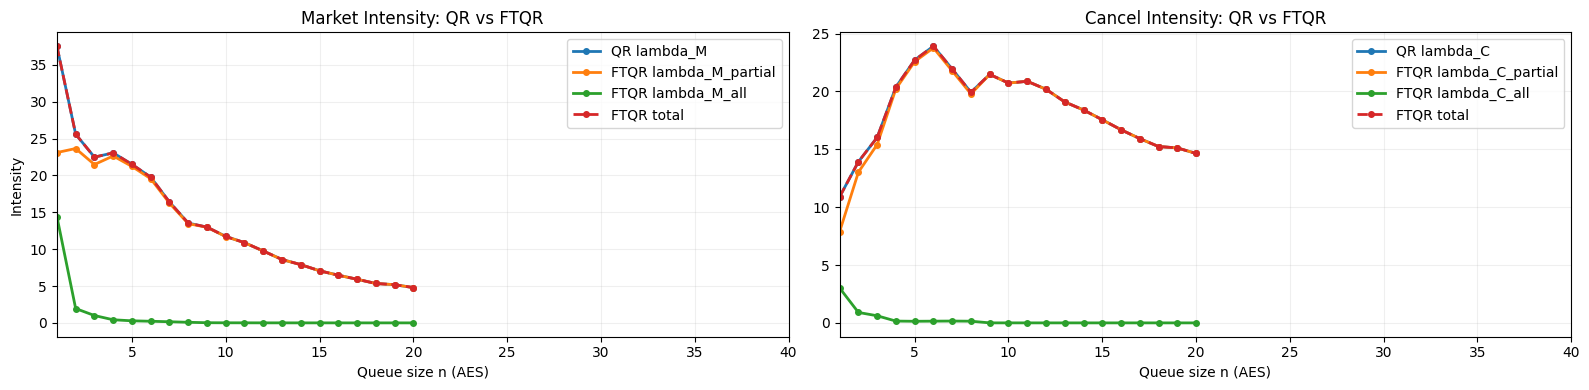

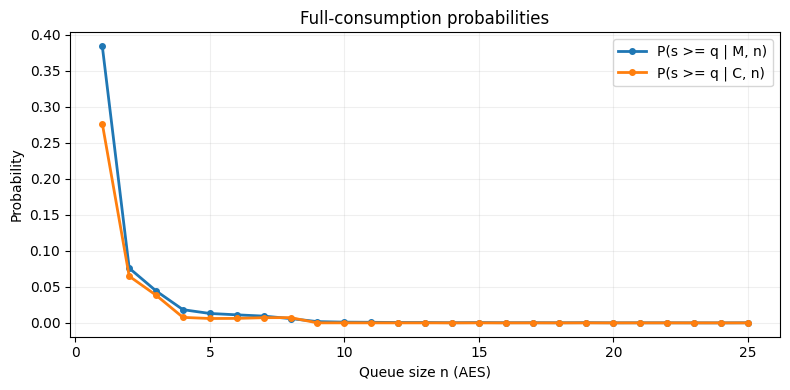

In [44]:
ftqr_identity_m = (ftqr_small["lambda_M_qr"] - (ftqr_small["lambda_M_ftqr"] + ftqr_small["lambda_M_all_ftqr"])).abs().max()
ftqr_identity_c = (ftqr_small["lambda_C_qr"] - (ftqr_small["lambda_C_ftqr"] + ftqr_small["lambda_C_all_ftqr"])).abs().max()
display(pd.DataFrame({"metric": ["max |M identity error|", "max |C identity error|"], "value": [ftqr_identity_m, ftqr_identity_c]}))

plot_df = ftqr_small[ftqr_small["n"] <= 40].copy()
marker_kws = dict(marker="o", markersize=4)
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
axes[0].plot(plot_df["n"], plot_df["lambda_M_qr"], linewidth=2, label="QR lambda_M", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_ftqr"], linewidth=2, label="FTQR lambda_M_partial", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_all_ftqr"], linewidth=2, label="FTQR lambda_M_all", **marker_kws)
axes[0].plot(plot_df["n"], plot_df["lambda_M_ftqr"] + plot_df["lambda_M_all_ftqr"], linewidth=2, linestyle="--", label="FTQR total", **marker_kws)
axes[0].set_title("Market Intensity: QR vs FTQR")
axes[0].set_xlabel("Queue size n (AES)")
axes[0].set_ylabel("Intensity")
axes[0].set_xlim(1, 40)
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(plot_df["n"], plot_df["lambda_C_qr"], linewidth=2, label="QR lambda_C", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_ftqr"], linewidth=2, label="FTQR lambda_C_partial", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_all_ftqr"], linewidth=2, label="FTQR lambda_C_all", **marker_kws)
axes[1].plot(plot_df["n"], plot_df["lambda_C_ftqr"] + plot_df["lambda_C_all_ftqr"], linewidth=2, linestyle="--", label="FTQR total", **marker_kws)
axes[1].set_title("Cancel Intensity: QR vs FTQR")
axes[1].set_xlabel("Queue size n (AES)")
axes[1].set_xlim(1, 40)
axes[1].grid(alpha=0.2)
axes[1].legend()
fig.tight_layout()

prob_plot = ftqr_full_probs[ftqr_full_probs["n"] <= 25].copy()
fig, ax = plt.subplots(figsize=(8, 4))
for eta, label in [("M", "P(s >= q | M, n)"), ("C", "P(s >= q | C, n)")]:
    sub = prob_plot[prob_plot["eta"] == eta]
    ax.plot(sub["n"], sub["p_full"], linewidth=2, marker="o", markersize=4, label=label)
ax.set_xlabel("Queue size n (AES)")
ax.set_ylabel("Probability")
ax.set_title("Full-consumption probabilities")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()

display(ftqr_sim)
display(Markdown(
    """
### FTQR Interpretation

- FTQR is implemented correctly when the decomposition identities hold numerically.
- FTQR redistributes intensity between partial and full-consumption events.
- FTQR does not alter the total `lambda_M(n)` or `lambda_C(n)` shape by itself; it only decomposes that shape.
- On this Bund dataset, full-consumption effects are concentrated mostly at the very smallest queues.
"""
))


## Conditional vs Stationary Size Distributions

The plots below compare the unconditional order-size distribution with the empirical conditional distributions at queue size `q = 30`, using the precomputed joint size tables.


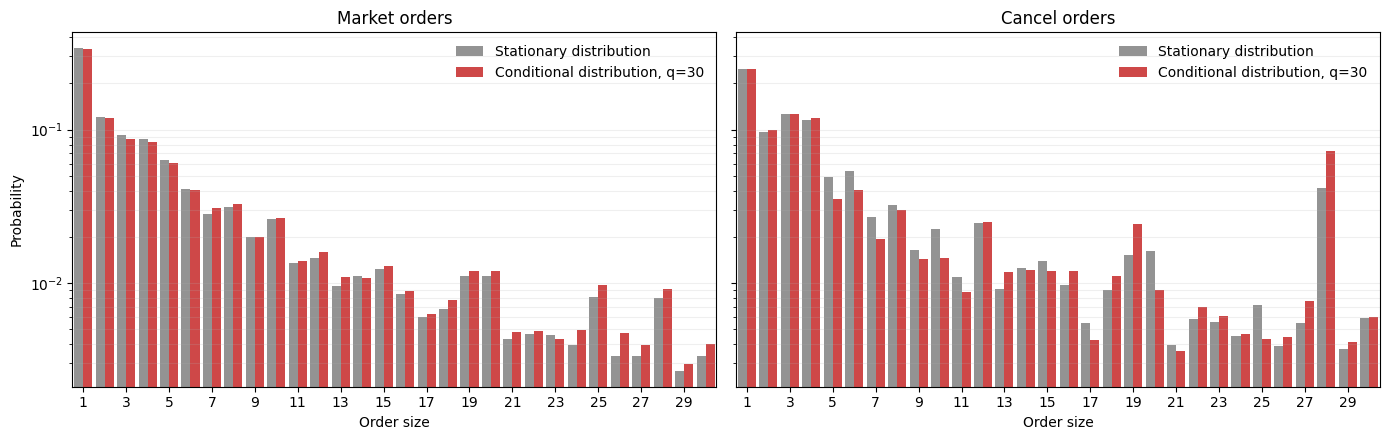

In [45]:
target_n = 30
max_size = 30
bar_width = 0.42
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, eta, title in zip(axes, ["M", "C"], ["Market orders", "Cancel orders"]):
    cond = joint_size[(joint_size["eta"] == eta) & (joint_size["n"] == target_n)].copy()
    uncond = eta_size_dist[eta_size_dist["eta"] == eta].copy()
    if cond.empty or uncond.empty:
        raise ValueError(f"No precomputed conditional size distribution is available for eta={eta}, q={target_n}.")

    cond = cond[["size", "count"]].rename(columns={"count": "count_cond"})
    uncond = uncond[["size", "count"]].rename(columns={"count": "count_uncond"})
    plot_df = cond.merge(uncond, on="size", how="outer").fillna(0.0)
    plot_df = plot_df[(plot_df["size"] > 0) & (plot_df["size"] <= max_size)].sort_values("size")
    plot_df["prob_cond"] = plot_df["count_cond"] / plot_df["count_cond"].sum()
    plot_df["prob_uncond"] = plot_df["count_uncond"] / plot_df["count_uncond"].sum()
    plot_df = plot_df[(plot_df["prob_cond"] > 0) | (plot_df["prob_uncond"] > 0)]

    x = plot_df["size"].to_numpy(dtype=float)
    ax.bar(x - bar_width / 2, plot_df["prob_uncond"], width=bar_width, color="gray", alpha=0.85, label="Stationary distribution")
    ax.bar(x + bar_width / 2, plot_df["prob_cond"], width=bar_width, color="#c62828", alpha=0.85, label=f"Conditional distribution, q={target_n}")
    ax.set_yscale("log")
    ax.set_xlim(0.5, max_size + 0.5)
    ax.set_xticks(np.arange(1, max_size + 1, 2))
    ax.set_title(title)
    ax.set_xlabel("Order size")
    ax.grid(axis="y", alpha=0.2, which="both")
    ax.legend(frameon=False)

axes[0].set_ylabel("Probability")
fig.tight_layout()
plt.show()


## QR vs QRU Intensities

QR and QRU share the same calibrated intensity curves; the difference between them is in the simulated event-size mechanism, not in the calibration itself.

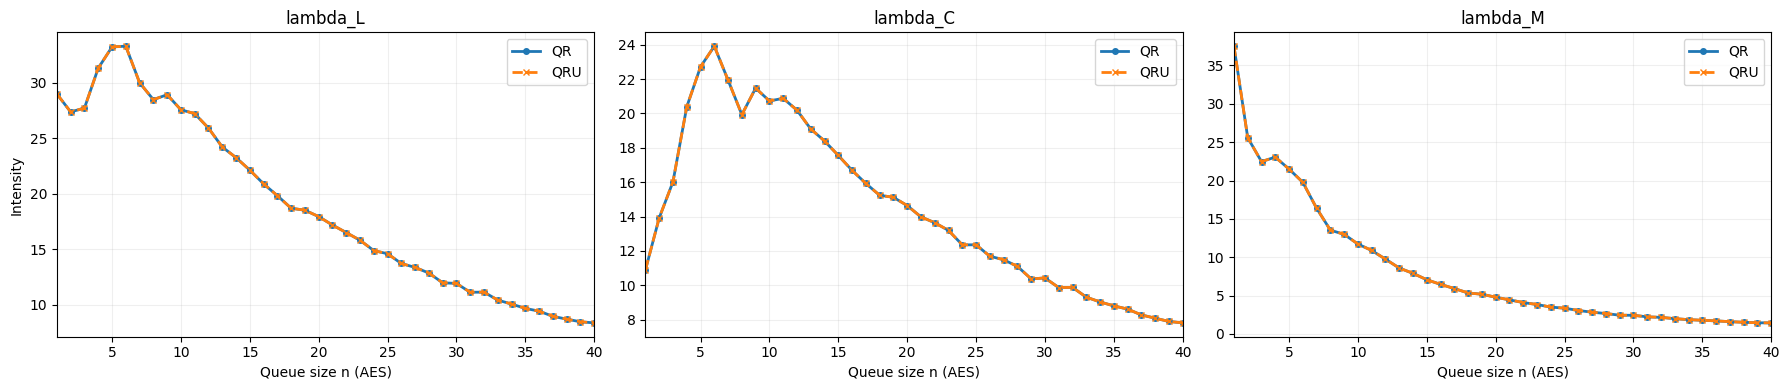

In [46]:
qr_plot = common_intensity[common_intensity["n"] <= 40].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, col, title in zip(axes, ["lambda_L", "lambda_C", "lambda_M"], ["lambda_L", "lambda_C", "lambda_M"]):
    ax.plot(qr_plot["n"], qr_plot[col], linewidth=2, marker="o", markersize=4, label="QR")
    ax.plot(qr_plot["n"], qr_plot[col], linewidth=2, linestyle="--", marker="x", markersize=4, label="QRU")
    ax.set_title(title)
    ax.set_xlabel("Queue size n (AES)")
    ax.set_xlim(1, 40)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylabel("Intensity")
fig.tight_layout()


## SAQR Diagnostics

The SAQR section uses AES-normalized queue size on the y-axis and AES-normalized order size on the x-axis. The first figure reports `log(1 + count)` support, which shows where the data are concentrated. The second figure reports the row-normalized conditional intensity, which is the most informative representation for assessing whether the dominant mass lies close to the diagonal.

For cancel and market orders, the upper-triangular region `s > q` is masked because it is not meaningful in the queue-consumption interpretation. The market-order panel also highlights the round-size buckets around 9, 17, and 26 AES, corresponding approximately to 50, 100, and 150 lots.


,metric,value
0,queue n min,1
1,queue n max,526
2,size_aes min,1
3,size_aes max,264
4,rows,14273


,eta,n,count
0,C,1,35653
1,C,2,41968
2,C,3,47306
3,C,4,50137
4,C,5,54570
5,C,6,56400
6,C,7,56630
7,C,8,60622
8,C,9,66380
9,C,10,68091


,eta,size_aes,count
0,C,1,4621639
1,C,2,629750
2,C,3,635496
3,C,4,140688
4,C,5,106075
5,C,6,62590
6,C,7,60459
7,C,8,78364
8,C,9,16767
9,C,10,10077


,eta,diag_mass,above_diag_mass,below_diag_mass,mass_at_9_17_26
0,C,0.0666,0.0024,0.9682,0.0003
1,M,0.2298,0.0001,0.8560,0.0005



### SAQR Interpretation

- Limit-order size distributions remain comparatively stable across queue sizes, with no strong diagonal dominance.
- For cancel and market orders, the diagonal region is visually dominant once the matrix is shown in row-normalized form and the non-meaningful `s > q` domain is masked.
- This diagonal dominance is strongest at small queue sizes, which is consistent with the idea that low available liquidity is more likely to be entirely consumed.
- In the market-order panels, the highlighted buckets around 9, 17, and 26 AES correspond to round trade sizes near 50, 100, and 150 lots.


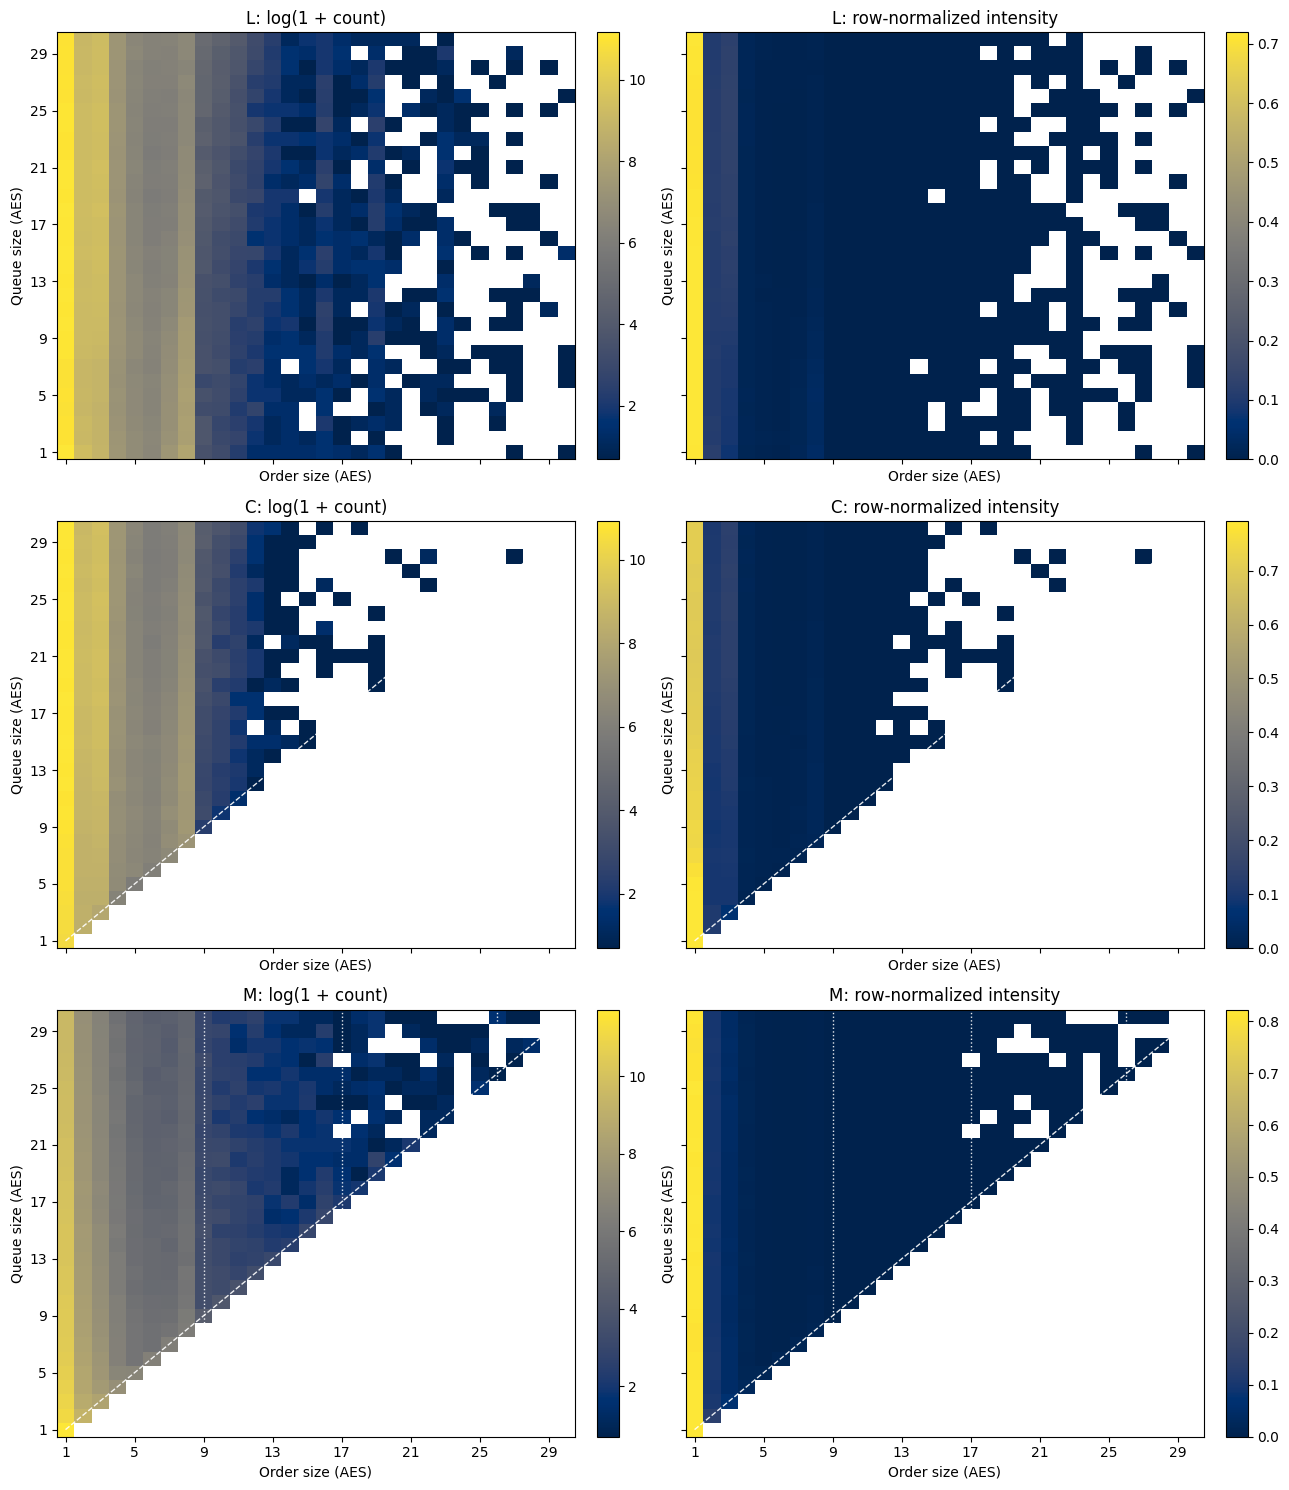

In [47]:
blue_yellow_cmap = plt.get_cmap("cividis")

support_by_n = saqr_aes.groupby(["eta", "n"], as_index=False)["count"].sum()
support_by_s = saqr_aes.groupby(["eta", "size_aes"], as_index=False)["count"].sum()
display(pd.DataFrame({
    "metric": ["queue n min", "queue n max", "size_aes min", "size_aes max", "rows"],
    "value": [saqr_aes["n"].min(), saqr_aes["n"].max(), saqr_aes["size_aes"].min(), saqr_aes["size_aes"].max(), len(saqr_aes)],
}))
display(support_by_n[support_by_n["n"] <= 20].head(20))
display(support_by_s[support_by_s["size_aes"] <= 20].head(20))

def build_heatmap(df, eta, value_col, triangular):
    sub = df[(df["eta"] == eta) & (df["n"] <= AES_CROP_MAX) & (df["size_aes"] <= AES_CROP_MAX)].copy()
    heat = sub.pivot(index="n", columns="size_aes", values=value_col).sort_index().sort_index(axis=1)
    heat = heat.reindex(index=range(1, AES_CROP_MAX + 1), columns=range(1, AES_CROP_MAX + 1))
    if triangular:
        for n in heat.index:
            heat.loc[n, heat.columns > n] = np.nan
    return heat

def plot_heatmap(ax, heat, title, cmap, vmin=None, vmax=None, add_diag=False, round_buckets=None):
    masked = np.ma.masked_invalid(heat.to_numpy(dtype=float))
    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
        extent=[0.5, heat.shape[1] + 0.5, 0.5, heat.shape[0] + 0.5],
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Order size (AES)")
    ax.set_ylabel("Queue size (AES)")
    ax.set_xticks(np.arange(1, AES_CROP_MAX + 1, 4))
    ax.set_yticks(np.arange(1, AES_CROP_MAX + 1, 4))
    if add_diag:
        ax.plot([1, AES_CROP_MAX], [1, AES_CROP_MAX], linestyle="--", linewidth=1.0, color="white", alpha=0.9)
    if round_buckets:
        for bucket in round_buckets:
            if bucket <= AES_CROP_MAX:
                ax.axvline(bucket, color="white", linestyle=":", linewidth=1.0, alpha=0.9)
    return im

support_heatmaps = {
    eta: build_heatmap(saqr_aes.assign(log_count=np.log1p(saqr_aes["count"])), eta, "log_count", triangular=(eta != "L"))
    for eta in ["L", "C", "M"]
}
row_heatmaps = {eta: build_heatmap(saqr_aes, eta, "row_prob", triangular=(eta != "L")) for eta in ["L", "C", "M"]}

fig, axes = plt.subplots(3, 2, figsize=(13, 15), sharex=True, sharey=True)
for row_idx, eta in enumerate(["L", "C", "M"]):
    support_im = plot_heatmap(
        axes[row_idx, 0],
        support_heatmaps[eta],
        f"{eta}: log(1 + count)",
        cmap=blue_yellow_cmap,
        add_diag=(eta != "L"),
        round_buckets=[9, 17, 26] if eta == "M" else None,
    )
    row_im = plot_heatmap(
        axes[row_idx, 1],
        row_heatmaps[eta],
        f"{eta}: row-normalized intensity",
        cmap=blue_yellow_cmap,
        vmin=0.0,
        vmax=np.nanquantile(row_heatmaps[eta].to_numpy(dtype=float), 0.99),
        add_diag=(eta != "L"),
        round_buckets=[9, 17, 26] if eta == "M" else None,
    )
    fig.colorbar(support_im, ax=axes[row_idx, 0], fraction=0.046, pad=0.04)
    fig.colorbar(row_im, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)
fig.tight_layout()

diag_rows = []
for eta in ["C", "M"]:
    sub = saqr_aes[(saqr_aes["eta"] == eta) & (saqr_aes["n"] <= AES_CROP_MAX) & (saqr_aes["size_aes"] <= AES_CROP_MAX)].copy()
    total = sub["lambda_eta_size"].sum()
    diag = sub[np.abs(sub["size_aes"] - sub["n"]) <= 1]["lambda_eta_size"].sum()
    above = sub[sub["size_aes"] > sub["n"]]["lambda_eta_size"].sum()
    below = sub[sub["size_aes"] < sub["n"]]["lambda_eta_size"].sum()
    bucket_mass = sub[sub["size_aes"].isin([9, 17, 26])]["lambda_eta_size"].sum()
    diag_rows.append({
        "eta": eta,
        "diag_mass": diag / total if total else np.nan,
        "above_diag_mass": above / total if total else np.nan,
        "below_diag_mass": below / total if total else np.nan,
        "mass_at_9_17_26": bucket_mass / total if total else np.nan,
    })
diag_df = pd.DataFrame(diag_rows)
display(diag_df.style.format({
    "diag_mass": "{:.4f}",
    "above_diag_mass": "{:.4f}",
    "below_diag_mass": "{:.4f}",
    "mass_at_9_17_26": "{:.4f}",
}))

display(Markdown(
    """
### SAQR Interpretation

- Limit-order size distributions remain comparatively stable across queue sizes, with no strong diagonal dominance.
- For cancel and market orders, the diagonal region is visually dominant once the matrix is shown in row-normalized form and the non-meaningful `s > q` domain is masked.
- This diagonal dominance is strongest at small queue sizes, which is consistent with the idea that low available liquidity is more likely to be entirely consumed.
- In the market-order panels, the highlighted buckets around 9, 17, and 26 AES correspond to round trade sizes near 50, 100, and 150 lots.
"""
))

